# Adding a new analysis

An **analysis** computes the state update for one assimilation iteration. It is
the piece that turns the current ensemble and its predicted data into a step.

The analysis is a *parameter* of a scheme, not a scheme of its own:

```python
ESMDA(cfg_da, cfg_en, sim, analysis="approx")
```

so adding one means writing a class and listing it, not copying a scheme.
This notebook writes a working analysis end to end and runs it against a
built-in one.

## The contract

One method:

```python
def update(self, enX, enY, enE, **kwargs) -> np.ndarray | None
```

| argument | shape | meaning |
| --- | --- | --- |
| `enX` | `(nx, ne)` | current state ensemble |
| `enY` | `(nd, ne)` | predicted data for that state |
| `enE` | `(nd, ne)` | perturbed observations |

Return the step to add to the state, shape `(nx, ne)` — or `None` if you
deliver the result by assignment instead (see the last section).

`AnalysisBase` also gives you two helpers that handle a covariance supplied
either as a full matrix or as just its diagonal:

In [1]:
import inspect
from pipt.update_schemes.analysis import AnalysisBase

print(inspect.signature(AnalysisBase.update))
print([m for m in ("solve", "sqrtm", "scheme") if hasattr(AnalysisBase, m)])
print("\n" + inspect.getdoc(AnalysisBase.solve))

(self, enX, enY, enE, **kwargs)
['solve', 'sqrtm', 'scheme']

Apply ``A⁻¹ B``, supporting both matrix (2-D) and diagonal (1-D) ``A``.

``np.ndim`` is used rather than ``A.ndim`` so that plain lists and
scalars -- which a covariance can still be when it comes straight from a
config file -- are handled instead of raising ``AttributeError``.


## Where the rest of the context comes from

Everything else is read off `self.scheme`. That is a *façade*: some of these
names are the scheme's own and some belong to its ensemble, but the scheme
exposes both as properties, so an analysis never has to know which.

| read | typically |
| --- | --- |
| `scheme.lam` | LM damping (0 for ES-MDA) |
| `scheme.trunc_energy` | SVD truncation energy |
| `scheme.iteration` | 0-based iteration counter |
| `scheme.proj` | centering/normalising projection, `(ne, ne)` |
| `scheme.cov_data`, `scheme.scale_data` | data covariance and its factor |
| `scheme.prior_enX`, `scheme.state_scaling` | prior state and its scaling |
| `scheme.keys_da`, `scheme.localization` | config and localization |

If you need something no existing analysis uses, read it off `self.scheme`
too — and if the scheme does not expose it yet, adding one property there is
the whole change.

## A worked example

A damped Kalman gain, formed directly rather than through the truncated SVD
that `approx`/`full` use. Same textbook update, different numerics:

$$\mathrm{step} = X\,\tilde{Y}^{\mathsf T}\big(\tilde{Y}\tilde{Y}^{\mathsf T} + (1+\lambda)I\big)^{-1}\tilde{D}$$

where $X$ are state anomalies and $\tilde{Y}, \tilde{D}$ are data anomalies
and innovations scaled to unit data covariance.

In [2]:
import numpy as np
from pipt.update_schemes.analysis import AnalysisBase


class ridge_update(AnalysisBase):
    """Damped Kalman gain, formed directly instead of via a truncated SVD."""

    def update(self, enX, enY, enE, **kwargs):
        scheme = self.scheme

        PI  = scheme.proj                       # (ne, ne)
        scy = scheme.scale_data                 # Cholesky factor of C_d

        X  = enX @ PI                           # state anomalies      (nx, ne)
        Ys = self.solve(scy, enY @ PI)          # scaled data anomalies (nd, ne)
        D  = self.solve(scy, enE - enY)         # scaled innovations    (nd, ne)

        A = Ys @ Ys.T + (1.0 + scheme.lam) * np.eye(Ys.shape[0])
        return X @ Ys.T @ np.linalg.solve(A, D)

print(ridge_update.__mro__[:2])

(<class '__main__.ridge_update'>, <class 'pipt.update_schemes.analysis.base.AnalysisBase'>)


## Wiring it in

`COMPATIBLE_ANALYSES` maps a flavour name to its class, per scheme. To offer a
new flavour on an existing scheme, subclass and extend the dict:

In [3]:
from pipt import LMEnRML

class RidgeEnRML(LMEnRML):
    COMPATIBLE_ANALYSES = {**LMEnRML.COMPATIBLE_ANALYSES, "ridge": ridge_update}

print("flavours on LMEnRML   :", sorted(LMEnRML.COMPATIBLE_ANALYSES))
print("flavours on RidgeEnRML:", sorted(RidgeEnRML.COMPATIBLE_ANALYSES))

flavours on LMEnRML   : ['approx', 'full', 'subspace']
flavours on RidgeEnRML: ['approx', 'full', 'ridge', 'subspace']


Asking for a flavour a scheme does not have fails immediately, and says what
is available — rather than failing later inside the numerics:

In [4]:
try:
    LMEnRML.COMPATIBLE_ANALYSES["ridge"]
except KeyError:
    print("LMEnRML has no 'ridge' -- as expected")

scheme_cls = RidgeEnRML
print("RidgeEnRML resolves 'ridge' ->", scheme_cls.COMPATIBLE_ANALYSES["ridge"].__name__)

LMEnRML has no 'ridge' -- as expected
RidgeEnRML resolves 'ridge' -> ridge_update


## A case to try it on

A 60-cell state observed at every 5th position — instant to run.

In [5]:
import os, tempfile
from copy import deepcopy
import numpy as np
from misc.structures import PETDataFrame
from simulator.simple_models import lin_1d

# A 60-cell state observed at every 5th position. Pure numpy, runs instantly.
STATE_SIZE = 60
CFG_SIM = {"reporttype": "position", "reportpoint": list(range(5, STATE_SIZE, 5)),
           "datatype": ["value"],
           # NOTE: >1 is deliberate. lin_1d returns a shared internal object from
           # run_fwd_sim, so a sequential run aliases every member onto the same
           # prediction and the ensemble collapses to zero spread.
           "parallel": 4}

CFG_ENS = {"ne": 50, "state": "x",
           "prior_x": {"vario": "sph", "mean": [0.0] * STATE_SIZE, "var": 1.0,
                       "range": 20.0, "aniso": 1.0, "angle": 0.0,
                       "grid": [STATE_SIZE, 1]}}

def cfg_da(analysis, **iteration):
    it = {"max_iter": 6, "data_misfit_tol": 1e-3, "lambda": 5.0,
          "lambda_factor": 4.0, "lambda_max": 1e8}
    it.update(iteration)
    return {"scheme": "custom", "analysis": analysis, "energy": 0.95,
            "obsname": "position", "data": "true_data.pkl", "datavar": "var.pkl",
            "iteration": it}

def make_truth():
    """Write the synthetic observations the schemes below assimilate.

    Returns the true state, so the plots can compare against it.
    """
    np.random.seed(10)
    sim = lin_1d(CFG_SIM); sim.setup_fwd_run()
    state = {"x": np.random.multivariate_normal(np.zeros(STATE_SIZE), np.eye(STATE_SIZE))}
    pred = PETDataFrame.from_records(sim.run_fwd_sim(state, 0), index=CFG_SIM["reportpoint"])
    data, var = pred.copy(), pred.copy()
    for c in data.columns:
        data[c] = data[c].apply(np.squeeze)
        var[c] = var[c].apply(lambda _: ["abs", 1.0])
    data.to_pickle("true_data.pkl"); var.to_pickle("var.pkl")
    return state["x"]

os.chdir(tempfile.mkdtemp())   # keep run artifacts out of the docs tree
TRUE_STATE = make_truth()
OBS_AT = CFG_SIM["reportpoint"]
print(f"case ready: {STATE_SIZE}-cell state, {len(OBS_AT)} observations, ne={CFG_ENS['ne']}")

case ready: 60-cell state, 11 observations, ne=50


Now run the built-in `full` flavour and the new `ridge` one on identical inputs:

In [6]:
results = {}
for label, cls, flavour in [("full (built-in)", LMEnRML, "full"),
                            ("ridge (new)",     RidgeEnRML, "ridge")]:
    np.random.seed(10)
    res = cls.assimilate(cfg_da(flavour), deepcopy(CFG_ENS),
                         lin_1d(CFG_SIM), analysis=flavour)
    results[label] = res
    print(f"{label:16}  misfit {res.prior_data_misfit:7.2f} -> {res.data_misfit:6.2f}"
          f"   iterations={res.nit}")

2026-08-24│11:33:03 :  =========== Running Data Assimilation - CUSTOM ===========


  0%|                                                                              | 0/50 [00:00<?, ?member/s]

2026-08-24│11:33:03 : 


2026-08-24│11:33:03 :  ┌─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐


2026-08-24│11:33:03 :  │  Iteration  │   Status    │ Data Misfit │ Change (%)  │      λ      │


...

2026-08-24│11:33:04 :  λ reduced: 0.01953125 ──> 0.0048828125


2026-08-24│11:33:04 : Maximum iterations reached without convergence.


2026-08-24│11:33:04 :  
 Convergence was met. Obj. function reduced from 30.0 to 5.9


2026-08-24│11:33:04 :  Assimilation finished after 5 iteration(s): Maximum number of iterations reached


ridge (new)       misfit   29.98 ->   5.94   iterations=5


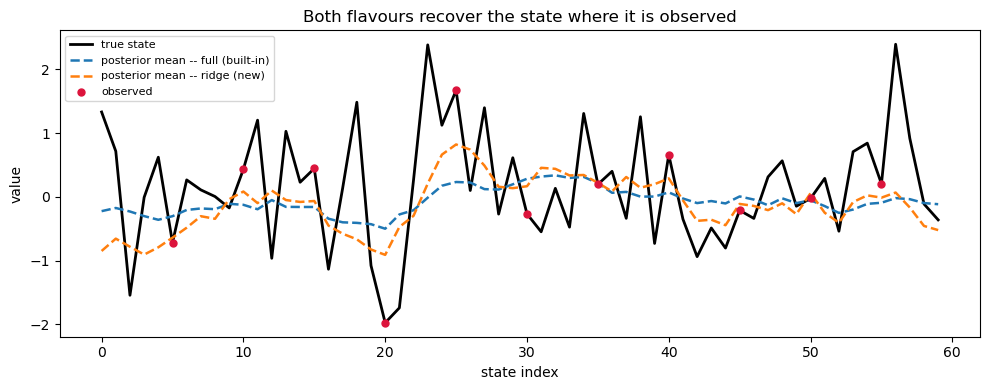

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(TRUE_STATE, "k-", lw=2, label="true state")
for label, res in results.items():
    ax.plot(np.asarray(res.x).mean(axis=-1), "--", lw=1.8, label=f"posterior mean -- {label}")
ax.scatter(OBS_AT, TRUE_STATE[OBS_AT], c="crimson", zorder=5, s=25, label="observed")
ax.set_xlabel("state index"); ax.set_ylabel("value")
ax.set_title("Both flavours recover the state where it is observed")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Steps that are not in state space

Some analyses do not compute a state-space step at all. `subspace_update`
solves in ensemble-weight space and returns `AnalysisResult(w_step=...)`;
`margIS_update` returns `AnalysisResult(W_step=...)`. The scheme's
`propose_state` then reconstructs the state, with a different formula for each:

| returns | reconstruction |
| --- | --- |
| a step (or `AnalysisResult(step=...)`) | `enX + step` |
| `AnalysisResult(w_step=...)` | `prior_enX @ (I + W / sqrt(ne-1))` |
| `AnalysisResult(W_step=...)` | `mean(prior_enX) + prior_enX @ proj @ W * sqrt(ne-1)` |

These are **not** interchangeable — the two `W`s are defined differently (one
starts at zero, the other at the identity). State the analysis keeps between
iterations (a cached matrix, the current `W`) lives on `self.scheme`, not on
`self`; the result itself is returned, never assigned.

## Checklist

1. Subclass `AnalysisBase`, implement `update(enX, enY, enE, **kwargs)`.
2. Read context off `self.scheme`; use `self.solve` / `self.sqrtm` for
   covariances that may be diagonal.
3. Return the step -- a plain array, or an `AnalysisResult` with `step`,
   `w_step` or `W_step` set.
4. List it in the scheme's `COMPATIBLE_ANALYSES`.
5. Run it against a built-in flavour on a case you understand — a new analysis
   that runs without erroring is not the same as one that is correct.